<a href="https://colab.research.google.com/github/mcenzie-K/Adaptive-collision-detection-system/blob/main/collision_avoidance_prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
"""
SIH26037 Prototype: Adaptive Path Planning & Collision Avoidance
for Autonomous Vehicles on Unstructured Indian Roads

Demonstrates the core pipeline in a simplified 2D grid simulation:
  Sensors -> Perception -> Mapping -> Global Planning (A*) ->
  Local Collision Avoidance (replanning) -> Vehicle Control

Static obstacles = potholes / permanent road damage (known in advance)
Dynamic obstacles = pedestrians / stray cattle (appear during the drive,
                     unknown until they enter the vehicle's sensor range)
"""

import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, PillowWriter

random.seed(7)
np.random.seed(7)

# ----------------------------- Grid World -----------------------------
GRID_W, GRID_H = 26, 15
SENSOR_RADIUS = 4          # how far the vehicle can "see" dynamic obstacles
START = (1, 7)
GOAL = (24, 7)

# Static obstacles: simulate roadside structures / large permanent potholes
STATIC_OBSTACLES = set()
random.seed(11)
for _ in range(30):
    x = random.randint(4, GRID_W - 5)
    y = random.randint(0, GRID_H - 1)
    if (x, y) not in (START, GOAL):
        STATIC_OBSTACLES.add((x, y))

# Force a couple of obstacle clusters directly across the straight-line route
# so the planner must visibly detour (more representative of a real road).
for x in [7, 8, 9]:
    STATIC_OBSTACLES.add((x, 7))
    STATIC_OBSTACLES.add((x, 6))
for x in [15, 16]:
    STATIC_OBSTACLES.add((x, 7))
    STATIC_OBSTACLES.add((x, 8))
STATIC_OBSTACLES.discard(START)
STATIC_OBSTACLES.discard(GOAL)

# Dynamic obstacles (pedestrian / cattle) — each has a scripted path and only
# "exists" in the planner's knowledge once within SENSOR_RADIUS of the vehicle
class DynamicObstacle:
    def __init__(self, kind, path):
        self.kind = kind          # 'pedestrian' or 'cattle'
        self.path = path          # list of (x, y) positions over time
    def position(self, t):
        idx = min(t, len(self.path) - 1)
        return self.path[idx]

def build_crossing(x_fixed, pre_delay, y_start, y_end, cross_len, total_len):
    """Obstacle sits off-grid (invisible) for `pre_delay` steps, then crosses
    from y_start to y_end over `cross_len` steps at fixed x, then holds."""
    positions = [(x_fixed, -10)] * pre_delay
    ys = np.linspace(y_start, y_end, cross_len)
    positions += [(x_fixed, int(round(y))) for y in ys]
    while len(positions) < total_len:
        positions.append(positions[-1])
    return positions

# Timed so each obstacle actually crosses the vehicle's planned path and
# forces a visible replan (matched against the base A* path timings).
DYNAMIC_OBSTACLES = [
    DynamicObstacle("cattle", build_crossing(x_fixed=8, pre_delay=4, y_start=2, y_end=12, cross_len=8, total_len=40)),
    DynamicObstacle("pedestrian", build_crossing(x_fixed=19, pre_delay=13, y_start=1, y_end=11, cross_len=9, total_len=40)),
]

# ----------------------------- A* Planner -----------------------------
def neighbors(node):
    x, y = node
    for dx, dy in [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]:
        nx, ny = x+dx, y+dy
        if 0 <= nx < GRID_W and 0 <= ny < GRID_H:
            yield (nx, ny)

def heuristic(a, b):
    return np.hypot(a[0]-b[0], a[1]-b[1])

def astar(start, goal, blocked):
    open_set = [(0, start)]
    came_from = {}
    g_score = {start: 0}
    while open_set:
        _, current = heapq.heappop(open_set)
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]
        for nb in neighbors(current):
            if nb in blocked:
                continue
            step_cost = heuristic(current, nb)
            tentative_g = g_score[current] + step_cost
            if tentative_g < g_score.get(nb, float('inf')):
                came_from[nb] = current
                g_score[nb] = tentative_g
                f = tentative_g + heuristic(nb, goal)
                heapq.heappush(open_set, (f, nb))
    return None  # no path found

# ----------------------------- Simulation Loop -----------------------------
def simulate():
    vehicle_pos = START
    known_dynamic_blocked = set()
    path = astar(vehicle_pos, GOAL, STATIC_OBSTACLES)
    history = []   # list of dicts per frame: vehicle pos, path, visible obstacles, replanned flag
    t = 0
    max_steps = 200
    path_idx = 1

    while vehicle_pos != GOAL and t < max_steps:
        # Determine currently visible dynamic obstacle positions (within sensor range)
        visible_dyn = {}
        for obs in DYNAMIC_OBSTACLES:
            p = obs.position(t)
            if heuristic(p, vehicle_pos) <= SENSOR_RADIUS:
                visible_dyn[p] = obs.kind

        replanned = False
        # Check if the upcoming portion of the path is blocked by a newly visible obstacle
        upcoming = path[path_idx:path_idx+6] if path else []
        if any(p in visible_dyn for p in upcoming):
            blocked = STATIC_OBSTACLES | set(visible_dyn.keys())
            new_path = astar(vehicle_pos, GOAL, blocked)
            if new_path:
                path = new_path
                path_idx = 1
                replanned = True

        history.append({
            "vehicle": vehicle_pos,
            "path": list(path),
            "visible_dyn": dict(visible_dyn),
            "all_dyn_true_pos": {obs.position(t): obs.kind for obs in DYNAMIC_OBSTACLES},
            "replanned": replanned,
            "t": t,
        })

        # Advance vehicle along the path
        if path_idx < len(path):
            vehicle_pos = path[path_idx]
            path_idx += 1
        t += 1

    # Record the final frame (vehicle at goal) which the loop-exit check would otherwise skip
    history.append({
        "vehicle": vehicle_pos,
        "path": list(path),
        "visible_dyn": {},
        "all_dyn_true_pos": {obs.position(t): obs.kind for obs in DYNAMIC_OBSTACLES},
        "replanned": False,
        "t": t,
    })

    return history

history = simulate()
print(f"Simulation finished in {len(history)} steps. Reached goal: {history[-1]['vehicle'] == GOAL}")

# ----------------------------- Visualization -----------------------------
fig, ax = plt.subplots(figsize=(11, 6.2))

def draw_frame(i):
    ax.clear()
    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect('equal')
    ax.set_facecolor('#3d3d3d')  # road surface
    ax.set_xticks([])
    ax.set_yticks([])

    frame = history[i]

    # Lane-less road: subtle grid texture instead of lane markings (unstructured road)
    for gx in range(0, GRID_W, 1):
        ax.axvline(gx, color='#4a4a4a', linewidth=0.3, zorder=0)

    # Static obstacles (potholes)
    for (x, y) in STATIC_OBSTACLES:
        ax.add_patch(patches.Circle((x, y), 0.32, facecolor='#6b4423', edgecolor='black', zorder=2))

    # Dynamic obstacles: true positions shown faded, "sensed" ones highlighted
    for pos, kind in frame["all_dyn_true_pos"].items():
        sensed = pos in frame["visible_dyn"]
        color = "#FFC107" if kind == "cattle" else "#03A9F4"
        alpha = 1.0 if sensed else 0.25
        marker = "s" if kind == "cattle" else "o"
        ax.scatter(*pos, s=180, c=color, marker=marker, edgecolors='black', alpha=alpha, zorder=4)
        if sensed:
            ax.add_patch(patches.Circle(frame["vehicle"], SENSOR_RADIUS, fill=False,
                                         edgecolor='#00E676', linestyle='--', linewidth=1.2, zorder=3))

    # Planned path
    path = frame["path"]
    if path:
        xs, ys = zip(*path)
        ax.plot(xs, ys, color='#00E676' if not frame["replanned"] else '#FF5252',
                 linewidth=2.5, alpha=0.85, zorder=3)

    # Start & Goal
    ax.scatter(*START, s=140, c='white', marker='*', edgecolors='black', zorder=5)
    ax.scatter(*GOAL, s=200, c='gold', marker='*', edgecolors='black', zorder=5)

    # Vehicle
    ax.scatter(*frame["vehicle"], s=260, c='#E53935', marker='>', edgecolors='black', zorder=6)

    status = "REPLANNING (obstacle detected)" if frame["replanned"] else "On path"
    ax.set_title(f"Adaptive Path Planning on Unstructured Road  |  Step {frame['t']}  |  {status}",
                 fontsize=11, fontweight='bold', color='black')

    # Legend
    legend_elems = [
        plt.Line2D([0],[0], marker='>', color='w', markerfacecolor='#E53935', markersize=12, label='Vehicle'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#6b4423', markersize=10, label='Pothole (static)'),
        plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='#FFC107', markersize=10, label='Cattle (dynamic)'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#03A9F4', markersize=10, label='Pedestrian (dynamic)'),
        plt.Line2D([0],[0], color='#00E676', lw=2, label='Planned path'),
        plt.Line2D([0],[0], color='#FF5252', lw=2, label='Replanned path'),
    ]
    ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, -0.03),
              ncol=3, fontsize=8, frameon=False)

anim = FuncAnimation(fig, draw_frame, frames=len(history), interval=180)
anim.save('adaptive_path_planning_demo.gif', writer=PillowWriter(fps=6))
plt.close(fig)  # prevents the static leftover frame from also displaying


#print("GIF saved.")


Simulation finished in 24 steps. Reached goal: True
GIF saved.


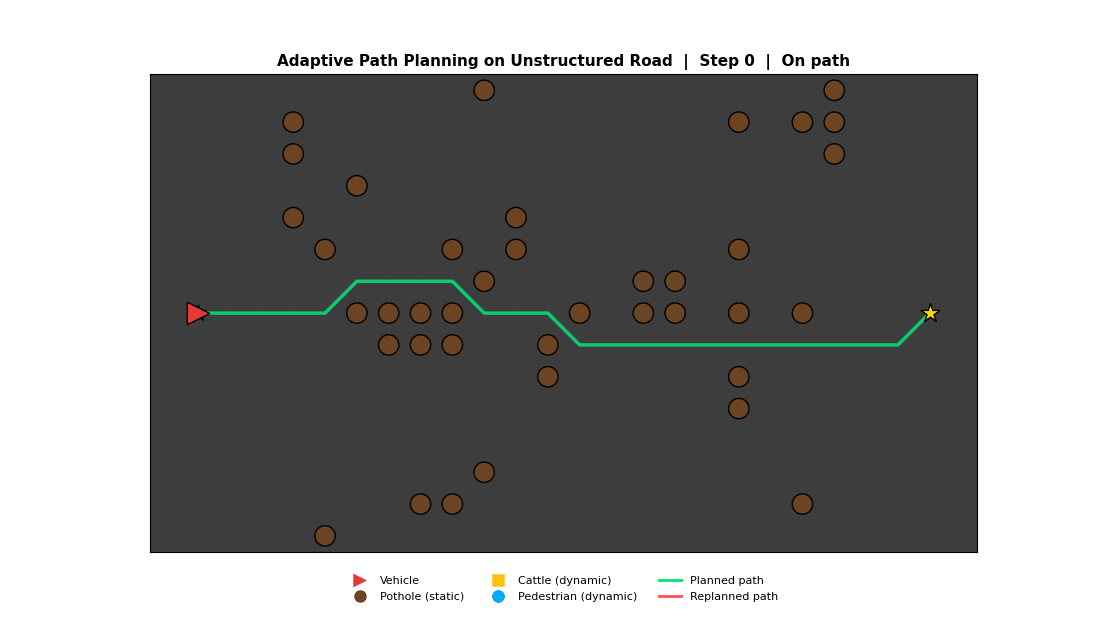

In [4]:
from IPython.display import Image as IPImage
IPImage(filename='adaptive_path_planning_demo.gif')